# 🚗 중고차 가격 예측 시스템 업그레이드 노트북

이 노트북은 기존 `머신러닝_cat.ipynb`를 발표/분석/재학습까지 한 번에 쓸 수 있도록 정리한 버전입니다.  
핵심 목표는 아래 4가지입니다.

1. **실제로 모델에 들어가는 피처를 명확하게 보여주기**
2. **OOF 기반 검증 흐름을 정리해서 leakage를 최대한 피하기**
3. **발표에 바로 쓸 수 있는 시각화 자료를 충분히 확보하기**
4. **최종 예측 함수와 저장 아티팩트까지 한 번에 만들기**

---

## 이 노트북에서 확인할 수 있는 것
- 데이터 기본 점검
- 특이 가격 제거 전후 비교
- 파생 변수 생성 로직
- 실제 사용 피처 목록 카탈로그
- 5-Fold OOF 기반 CatBoost 검증
- 그룹 분리 모델(`premium_young_flag`) 성능
- 잔차 분석 / 구간별 오류 분석
- 그룹별 Feature Importance
- 선택적으로 SHAP 시각화
- 최종 예측 함수 및 아티팩트 저장

> **권장 파일명**: `encar_feature_processed_for_quantile_safe.csv`  
> 노트북과 같은 폴더에 두고 실행하면 가장 편합니다.


## 실행 순서
1. 아래 환경 설정 셀 실행
2. CSV 경로 확인 후 데이터 로드
3. EDA와 피처 카탈로그 확인
4. CV 실행 후 OOF 성능 확인
5. 최종 모델 재학습 및 중요도/예측 함수 확인

> 발표용으로는 `데이터 점검 → 실제 사용 피처 → CV 성능 → 잔차 분석 → 최종 예측 예시` 흐름이 가장 깔끔합니다.


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="Glyph .* missing from current font")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.font_manager as fm

from IPython.display import display, Markdown, HTML

from sklearn.model_selection import KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from catboost import CatBoostRegressor, Pool
import joblib


def set_safe_korean_font():
    preferred_fonts = [
        "Malgun Gothic",
        "Apple SD Gothic Neo",
        "AppleGothic",
        "NanumGothic",
        "NanumBarunGothic",
        "Noto Sans CJK KR",
        "Noto Sans KR",
        "Arial Unicode MS",
    ]

    available_fonts = {f.name for f in fm.fontManager.ttflist}
    selected_font = next((f for f in preferred_fonts if f in available_fonts), None)

    if selected_font is not None:
        plt.rcParams["font.family"] = selected_font
    else:
        plt.rcParams["font.family"] = "DejaVu Sans"

    plt.rcParams["axes.unicode_minus"] = False
    plt.rcParams["figure.figsize"] = (10, 5)

    return selected_font


SELECTED_FONT = set_safe_korean_font()

if SELECTED_FONT is None:
    print("사용 가능한 한글 폰트를 찾지 못해 기본 폰트로 진행합니다. 그래프에서 한글이 깨지면 Malgun Gothic 또는 NanumGothic 설치 후 다시 실행해주세요.")
else:
    print(f"그래프 폰트 설정 완료: {SELECTED_FONT}")

TARGET = "현재가격_만원"
RANDOM_STATE = 42
N_SPLITS = 5

DATA_PATH = Path("encar_feature_processed_for_quantile_safe.csv")
ARTIFACT_PATH = Path("car_price_system_artifacts.pkl")
OOF_EXPORT_PATH = Path("oof_diagnostics.csv")


그래프 폰트 설정 완료: Malgun Gothic


> 참고  
> 그래프 폰트는 자동으로 설치된 한글 폰트를 찾도록 바꿔두었습니다.  
> 그래도 한글이 깨지면 `Malgun Gothic` 또는 `NanumGothic` 설치 후 맨 위 셀부터 다시 실행하면 됩니다.

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"데이터 파일을 찾지 못했습니다: {DATA_PATH.resolve()}\n"
        "노트북과 같은 폴더에 'encar_feature_processed_for_quantile_safe.csv'를 두고 다시 실행해주세요."
    )

df = pd.read_csv(DATA_PATH)
print("데이터 로드 완료")
print("shape:", df.shape)


데이터 로드 완료
shape: (11363, 46)


# 1. 데이터 기본 점검
먼저 **컬럼 구조 / 결측 / 타깃 분포 / 주요 범주**를 확인합니다.  
이 단계에서 데이터의 대략적인 상태를 잡아두면 뒤에서 나온 결과를 설명하기가 훨씬 편해집니다.


In [3]:
display(Markdown("### 데이터 미리보기"))
display(df.head())

basic_info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_cnt": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "nunique": df.nunique(dropna=False)
}).sort_values(["missing_pct", "nunique"], ascending=[False, False])

display(Markdown("### 컬럼 요약"))
display(basic_info)

display(Markdown("### 타깃 기초통계"))
display(df[TARGET].describe().to_frame().T)


### 데이터 미리보기

,매물ID,모델,모델_평균가_TE,현재가격_만원,주행거리_km,배기량_cc,좌석수,차량연령,사고강도점수,주요옵션_선루프,...,차급_SUV계열,차급_세단계열,flag_price_9999,flag_high_mileage,flag_non_ev_cc_zero,flag_cc_over_5000,flag_seat_over_12,flag_age_over_25,flag_accident_over_15,flag_non_ev_non_h2_cc_zero
0,37398208.0,렉스턴 스포츠 칸,2113.842105,1700.0,92801,2157.0,5,7,10,0,...,1,0,0,0,0,0,0,0,0,0
1,37424561.0,코란도 투리스모,658.918367,750.0,118621,2157.0,5,10,6,0,...,1,0,0,0,0,0,0,0,0,0
2,38020327.0,티볼리 에어,1023.075269,650.0,120313,1597.0,5,10,2,0,...,1,0,0,0,0,0,0,0,0,0
3,38261140.0,코란도 투리스모,658.918367,650.0,82255,1998.0,5,12,5,1,...,1,0,0,0,0,0,0,0,0,0
4,38349931.0,G4 렉스턴,1783.857143,1670.0,93678,2157.0,5,9,11,1,...,1,0,0,0,0,0,0,0,0,0


### 컬럼 요약

,dtype,missing_cnt,missing_pct,nunique
매물ID,float64,0,0.0,11363
주행거리_km,int64,0,0.0,10993
현재가격_만원,float64,0,0.0,1243
모델,object,0,0.0,324
모델_평균가_TE,float64,0,0.0,313
배기량_cc,float64,0,0.0,100
차량연령,int64,0,0.0,35
사고강도점수,int64,0,0.0,34
좌석수,int64,0,0.0,13
주요옵션_선루프,int64,0,0.0,2


### 타깃 기초통계

,count,mean,std,min,25%,50%,75%,max
현재가격_만원,11363.0,1999.859632,1480.060844,140.0,830.0,1660.0,2780.0,12590.0


In [4]:
missing_df = (
    df.isna().mean()
      .mul(100)
      .reset_index()
      .rename(columns={"index": "feature", 0: "missing_pct"})
)
missing_df = missing_df[missing_df["missing_pct"] > 0].sort_values("missing_pct", ascending=False)

if len(missing_df) == 0:
    print("결측치가 있는 컬럼이 없습니다.")
else:
    plt.figure(figsize=(12, 5))
    plt.bar(missing_df["feature"], missing_df["missing_pct"])
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Missing %")
    plt.title("컬럼별 결측 비율")
    plt.tight_layout()
    plt.show()


결측치가 있는 컬럼이 없습니다.


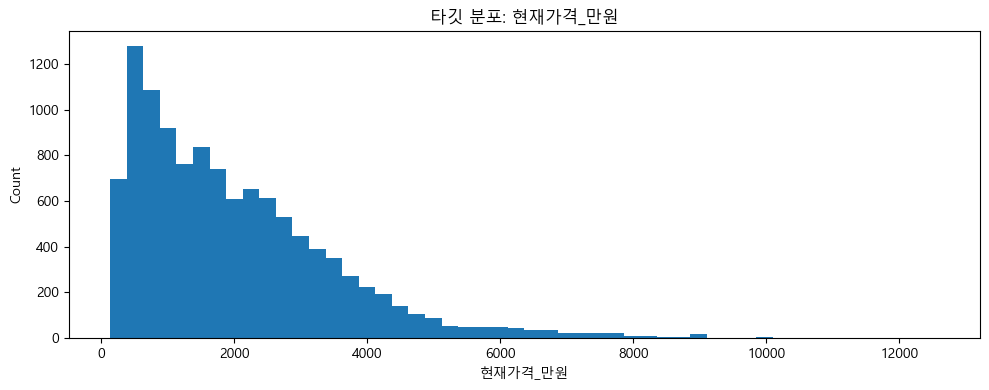

In [5]:
plt.figure(figsize=(10, 4))
plt.hist(df[TARGET].dropna(), bins=50)
plt.title("타깃 분포: 현재가격_만원")
plt.xlabel(TARGET)
plt.ylabel("Count")
plt.tight_layout()
plt.show()


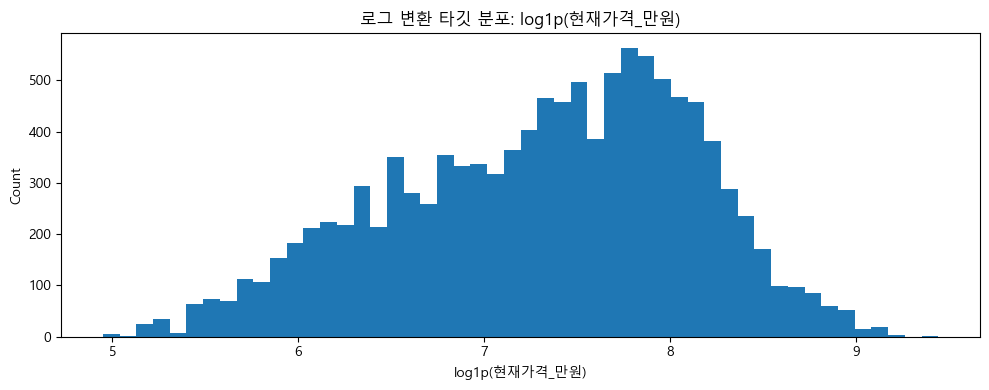

In [6]:
plt.figure(figsize=(10, 4))
plt.hist(np.log1p(df[TARGET].dropna()), bins=50)
plt.title("로그 변환 타깃 분포: log1p(현재가격_만원)")
plt.xlabel(f"log1p({TARGET})")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


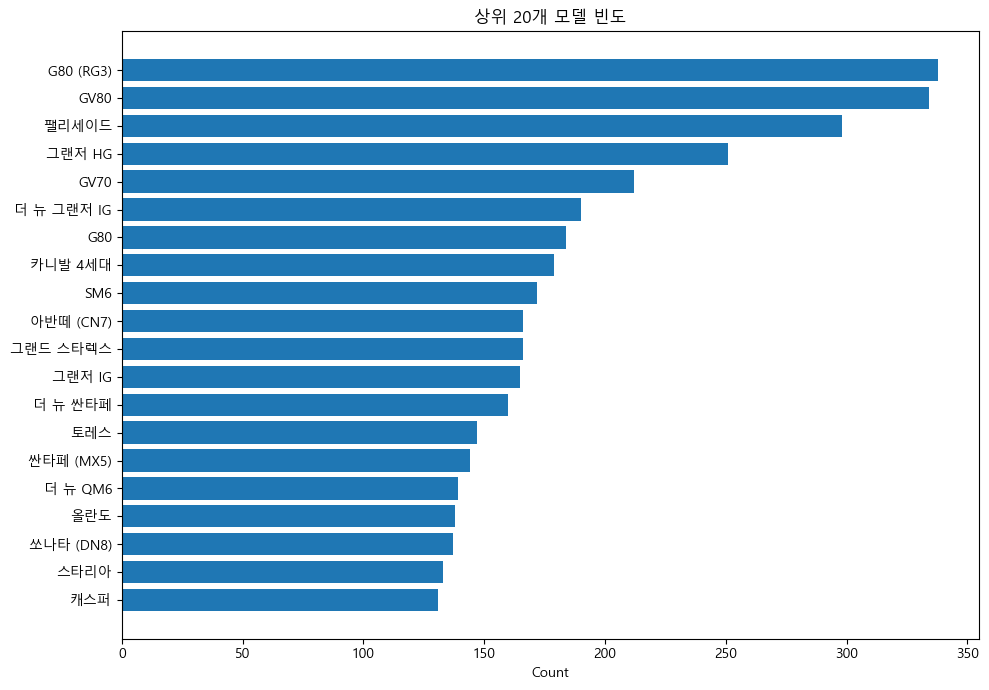

In [7]:
if "모델" in df.columns:
    top_models = df["모델"].value_counts().head(20).sort_values()
    plt.figure(figsize=(10, 7))
    plt.barh(top_models.index, top_models.values)
    plt.title("상위 20개 모델 빈도")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("'모델' 컬럼이 없어 모델 분포 시각화를 생략합니다.")


# 2. 특이 가격(special price) 점검 및 제거
기존 실험에서 `1111, 2222, 3333, ..., 9999, 9990` 같은 가격이 존재했습니다.  
이 값들은 실제 시장가격이라기보다 **등록 습관 / 임시 입력 / 비정상 기입값**일 가능성이 있어 분리해서 확인합니다.


In [8]:
special_exact = [1111, 2222, 3333, 4444, 5555, 6666, 7777, 8888, 9990, 9999]

price_int = df[TARGET].round().astype(int)
df["flag_special_price"] = price_int.isin(special_exact).astype(int)

special_summary = pd.DataFrame({
    "구분": ["원본 전체", "특이 가격", "정상 가격"],
    "건수": [len(df), int(df["flag_special_price"].sum()), int((df["flag_special_price"] == 0).sum())]
})
special_summary["비율(%)"] = (special_summary["건수"] / len(df) * 100).round(2)

display(special_summary)

display(Markdown("### 특이 가격 분포"))
display(
    df.loc[df["flag_special_price"] == 1, TARGET]
      .value_counts()
      .sort_index()
      .rename_axis("price")
      .reset_index(name="count")
)


,구분,건수,비율(%)
0,원본 전체,11363,100.00
1,특이 가격,39,0.34
2,정상 가격,11324,99.66


### 특이 가격 분포

,price,count
0,1111.0,3
1,2222.0,6
2,3333.0,2
3,4444.0,1
4,5555.0,1
5,7777.0,8
6,8888.0,15
7,9990.0,3


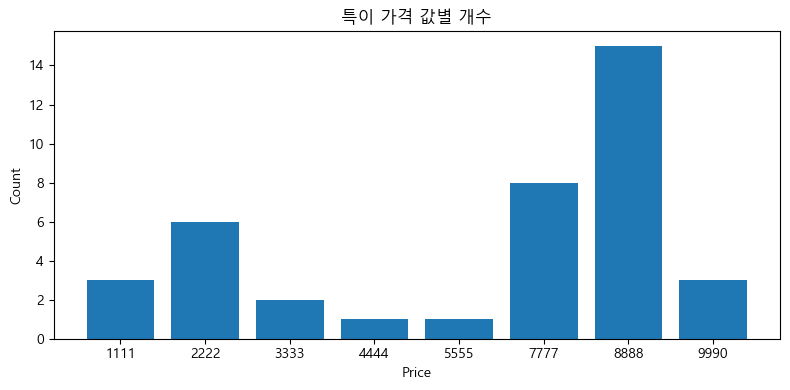

In [9]:
special_counts = (
    df.loc[df["flag_special_price"] == 1, TARGET]
      .round().astype(int)
      .value_counts()
      .sort_index()
)

if len(special_counts) > 0:
    plt.figure(figsize=(8, 4))
    plt.bar(special_counts.index.astype(str), special_counts.values)
    plt.title("특이 가격 값별 개수")
    plt.xlabel("Price")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("특이 가격이 없습니다.")


In [10]:
df_clean = df[df["flag_special_price"] == 0].copy()

compare_df = pd.DataFrame({
    "구분": ["원본", "특이 가격 제거 후"],
    "행수": [len(df), len(df_clean)],
    "평균가격": [df[TARGET].mean(), df_clean[TARGET].mean()],
    "중앙가격": [df[TARGET].median(), df_clean[TARGET].median()]
}).round(2)

display(compare_df)


,구분,행수,평균가격,중앙가격
0,원본,11363,1999.86,1660.0
1,특이 가격 제거 후,11324,1983.89,1650.0


# 3. 피처 엔지니어링 함수
아래 함수들은 이번 시스템의 핵심입니다.

- `add_features`: 파생 변수 생성
- `add_oof_te`: OOF Target Encoding 생성
- `build_te_mapping / apply_te_mapping`: 최종 학습 후 실서비스용 인코딩 적용
- `train_grouped_cv`: 그룹 분리 CatBoost 검증
- `train_price_system`: 최종 아티팩트 학습


In [11]:
def add_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()

    # 1) 기본 파생
    if "주행거리_km" in data.columns:
        data["log_주행거리"] = np.log1p(data["주행거리_km"])
    else:
        data["log_주행거리"] = 0

    if "차량연령" in data.columns:
        data["차량연령_sq"] = data["차량연령"] ** 2
    else:
        data["차량연령_sq"] = 0

    if {"주행거리_km", "차량연령"}.issubset(data.columns):
        data["연간주행거리"] = data["주행거리_km"] / np.maximum(data["차량연령"], 1)
    else:
        data["연간주행거리"] = 0

    # 2) 옵션 개수
    option_cols = [c for c in data.columns if c.startswith("주요옵션_")]
    data["옵션개수"] = data[option_cols].sum(axis=1) if option_cols else 0

    # 3) 사고 강도 구간화
    if "사고강도점수" in data.columns:
        data["사고강도_bin"] = pd.cut(
            data["사고강도점수"],
            bins=[-1, 0, 2, 6, 15, 100],
            labels=["0", "1-2", "3-6", "7-15", "16+"]
        ).astype(str)
    else:
        data["사고강도_bin"] = "unknown"

    # 4) 차량연령 구간화
    if "차량연령" in data.columns:
        data["연식구간"] = pd.cut(
            data["차량연령"],
            bins=[-1, 3, 7, 12, 20, 100],
            labels=["0-3", "4-7", "8-12", "13-20", "21+"]
        ).astype(str)
    else:
        data["연식구간"] = "unknown"

    # 5) 연료명 복원
    fuel_cols = [c for c in data.columns if c.startswith("연료_")]
    if fuel_cols:
        data["연료명"] = (
            data[fuel_cols]
            .idxmax(axis=1)
            .str.replace("연료_", "", regex=False)
        )
    else:
        data["연료명"] = "unknown"

    # 6) 결합 범주
    if "모델" in data.columns:
        data["모델_연식구간"] = data["모델"].astype(str) + "_" + data["연식구간"].astype(str)
        data["모델_연료"] = data["모델"].astype(str) + "_" + data["연료명"].astype(str)
    else:
        data["모델_연식구간"] = "unknown"
        data["모델_연료"] = "unknown"

    # 7) 그룹 분리용 flag
    genesis_flag = data["제조사_제네시스"] if "제조사_제네시스" in data.columns else 0
    ev_flag = data["연료_전기"] if "연료_전기" in data.columns else 0
    age_cond = (data["차량연령"] <= 5) if "차량연령" in data.columns else False
    engine_cond = (data["배기량_cc"] >= 3000) if "배기량_cc" in data.columns else False

    data["premium_young_flag"] = (
        age_cond | (genesis_flag == 1) | (ev_flag == 1) | engine_cond
    ).astype(int)

    return data


def add_oof_te(
    train_df: pd.DataFrame,
    valid_df: pd.DataFrame,
    col: str,
    target: str,
    n_splits: int = 5,
    smoothing: int = 20,
    random_state: int = 42
):
    train_df = train_df.copy()
    valid_df = valid_df.copy()

    global_mean = train_df[target].mean()
    oof = pd.Series(index=train_df.index, dtype=float)

    inner_kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for tr_idx, val_idx in inner_kf.split(train_df):
        tr = train_df.iloc[tr_idx]
        val = train_df.iloc[val_idx]

        stats = tr.groupby(col)[target].agg(["mean", "count"])
        smooth = (stats["count"] * stats["mean"] + smoothing * global_mean) / (stats["count"] + smoothing)

        oof.iloc[val_idx] = val[col].map(smooth).fillna(global_mean)

    full_stats = train_df.groupby(col)[target].agg(["mean", "count"])
    full_smooth = (full_stats["count"] * full_stats["mean"] + smoothing * global_mean) / (full_stats["count"] + smoothing)
    valid_te = valid_df[col].map(full_smooth).fillna(global_mean)

    return oof, valid_te


def build_te_mapping(train_df: pd.DataFrame, col: str, target: str, smoothing: int = 20):
    global_mean = train_df[target].mean()
    stats = train_df.groupby(col)[target].agg(["mean", "count"])
    smooth = (stats["count"] * stats["mean"] + smoothing * global_mean) / (stats["count"] + smoothing)

    return {
        "mapping": smooth.to_dict(),
        "global_mean": float(global_mean),
        "smoothing": smoothing,
        "column": col
    }


def apply_te_mapping(df_input: pd.DataFrame, col: str, te_info: dict, new_col: str):
    df_input = df_input.copy()
    df_input[new_col] = df_input[col].map(te_info["mapping"]).fillna(te_info["global_mean"])
    return df_input


def get_group_params(group_flag: int):
    # 현재 챔피언 구조 기준. 필요하면 그룹별로 다르게 튜닝 가능
    return {
        "iterations": 5000,
        "learning_rate": 0.02,
        "depth": 5,
        "l2_leaf_reg": 12,
        "random_strength": 3,
        "bagging_temperature": 1,
    }


## 파생 변수 설명

| 변수명 | 설명 |
|---|---|
| `log_주행거리` | 주행거리의 오른쪽 꼬리를 줄이기 위한 로그 변환 |
| `차량연령_sq` | 연식 효과의 비선형성을 반영하기 위한 제곱항 |
| `연간주행거리` | 누적 주행거리보다 실제 사용 강도를 더 직접적으로 보기 위한 변수 |
| `옵션개수` | 옵션 개별 컬럼들을 하나의 총합 신호로 요약 |
| `사고강도_bin` | 사고강도점수를 설명 가능한 구간형 범주로 변환 |
| `연식구간` | 모델 세대 차이를 간접적으로 반영하기 위한 구간화 |
| `연료명` | 원핫 연료 컬럼에서 대표 연료명 복원 |
| `모델_연식구간` | 모델과 연식구간의 결합 범주 |
| `모델_연료` | 모델과 연료의 결합 범주 |
| `premium_young_flag` | 비교적 고가/신차급/전기차/대배기량 차량을 분리하기 위한 규칙 기반 플래그 |


# 4. 실제 사용 피처 카탈로그
여기가 발표에서 꽤 중요합니다.  
단순히 `컬럼이 많다`가 아니라, **어떤 컬럼이 실제로 모델에 들어가고 / 어떤 컬럼이 제외되고 / 어떤 컬럼이 중간 파생인지**를 명확히 보여줍니다.


In [12]:
df_model_base = add_features(df_clean.copy())

drop_cols = [TARGET, "매물ID", "모델_평균가_TE", "flag_special_price"]
drop_cols_present = [c for c in drop_cols if c in df_model_base.columns]

base_X = df_model_base.drop(columns=drop_cols_present).copy()

derived_features = [
    "log_주행거리",
    "차량연령_sq",
    "연간주행거리",
    "옵션개수",
    "사고강도_bin",
    "연식구간",
    "연료명",
    "모델_연식구간",
    "모델_연료",
    "premium_young_flag",
]

te_features = ["모델_TE", "모델_연식구간_TE", "모델_연료_TE"]
oof_te_features = ["모델_TE_OOF", "모델_연식구간_TE_OOF", "모델_연료_TE_OOF"]

feature_rows = []
for col in base_X.columns:
    if col in derived_features:
        feature_source = "derived"
    else:
        feature_source = "raw"

    if col.startswith("주요옵션_"):
        feature_group = "option_onehot"
    elif col.startswith("제조사_"):
        feature_group = "manufacturer_onehot"
    elif col.startswith("연료_"):
        feature_group = "fuel_onehot"
    elif col.startswith("색상_"):
        feature_group = "color_onehot"
    elif col in ["모델", "연료명", "연식구간", "모델_연식구간", "모델_연료", "사고강도_bin"]:
        feature_group = "categorical_text"
    elif feature_source == "derived":
        feature_group = "derived_numeric_or_categorical"
    else:
        feature_group = "raw_numeric_or_other"

    feature_rows.append({
        "feature": col,
        "dtype": str(base_X[col].dtype),
        "source": feature_source,
        "group": feature_group,
        "used_in_base_model_input": True
    })

feature_catalog = pd.DataFrame(feature_rows).sort_values(["source", "group", "feature"]).reset_index(drop=True)
display(feature_catalog)

display(Markdown(f"### 기본 입력 피처 수: **{base_X.shape[1]}개**"))
display(Markdown(f"### 제거된 컬럼: `{drop_cols_present}`"))
display(Markdown(f"### Fold 내부에서 추가되는 Target Encoding 피처: `{oof_te_features}`"))
display(Markdown(f"### 최종 전체학습 시 추가되는 Target Encoding 피처: `{te_features}`"))


,feature,dtype,source,group,used_in_base_model_input
0,모델_연료,object,derived,categorical_text,True
1,모델_연식구간,object,derived,categorical_text,True
2,사고강도_bin,object,derived,categorical_text,True
3,연료명,object,derived,categorical_text,True
4,연식구간,object,derived,categorical_text,True
5,log_주행거리,float64,derived,derived_numeric_or_categorical,True
6,premium_young_flag,int64,derived,derived_numeric_or_categorical,True
7,연간주행거리,float64,derived,derived_numeric_or_categorical,True
8,옵션개수,int64,derived,derived_numeric_or_categorical,True
9,차량연령_sq,int64,derived,derived_numeric_or_categorical,True


### 기본 입력 피처 수: **53개**

### 제거된 컬럼: `['현재가격_만원', '매물ID', '모델_평균가_TE', 'flag_special_price']`

### Fold 내부에서 추가되는 Target Encoding 피처: `['모델_TE_OOF', '모델_연식구간_TE_OOF', '모델_연료_TE_OOF']`

### 최종 전체학습 시 추가되는 Target Encoding 피처: `['모델_TE', '모델_연식구간_TE', '모델_연료_TE']`

,source,group,count
0,derived,categorical_text,5
1,derived,derived_numeric_or_categorical,5
7,raw,raw_numeric_or_other,16
6,raw,option_onehot,10
4,raw,fuel_onehot,6
5,raw,manufacturer_onehot,6
3,raw,color_onehot,4
2,raw,categorical_text,1


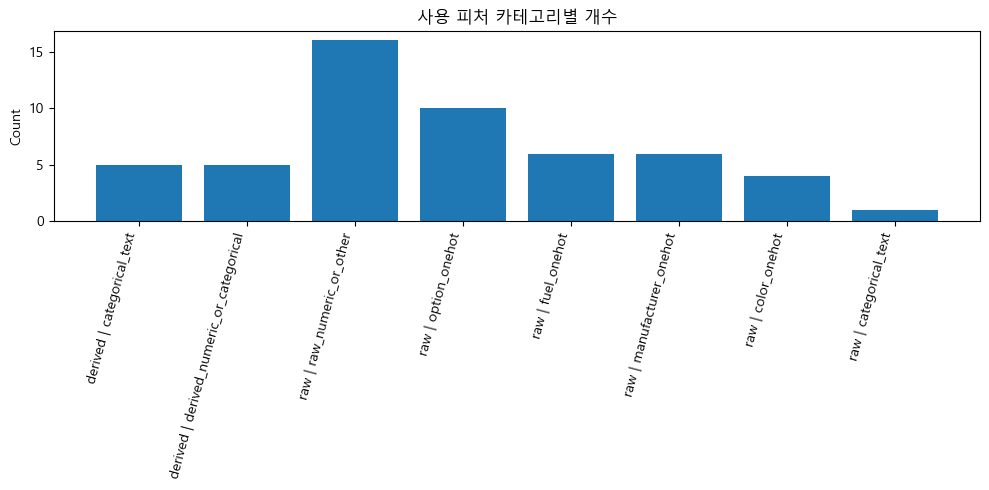

In [13]:
feature_group_summary = (
    feature_catalog.groupby(["source", "group"])
    .size()
    .reset_index(name="count")
    .sort_values(["source", "count"], ascending=[True, False])
)

display(feature_group_summary)

plt.figure(figsize=(10, 5))
plt.bar(
    feature_group_summary["source"] + " | " + feature_group_summary["group"],
    feature_group_summary["count"]
)
plt.xticks(rotation=75, ha="right")
plt.title("사용 피처 카테고리별 개수")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# 5. 모델링 전 탐색적 시각화
이 섹션은 **모델 설명용 그림**을 뽑기 좋습니다.

추천 발표 포인트:
- 가격은 단순 선형으로 움직이지 않음
- 주행거리, 연식, 사고강도, 옵션 수가 동시에 작동함
- 특정 그룹은 일반 차량과 다른 가격 구조를 가질 수 있음


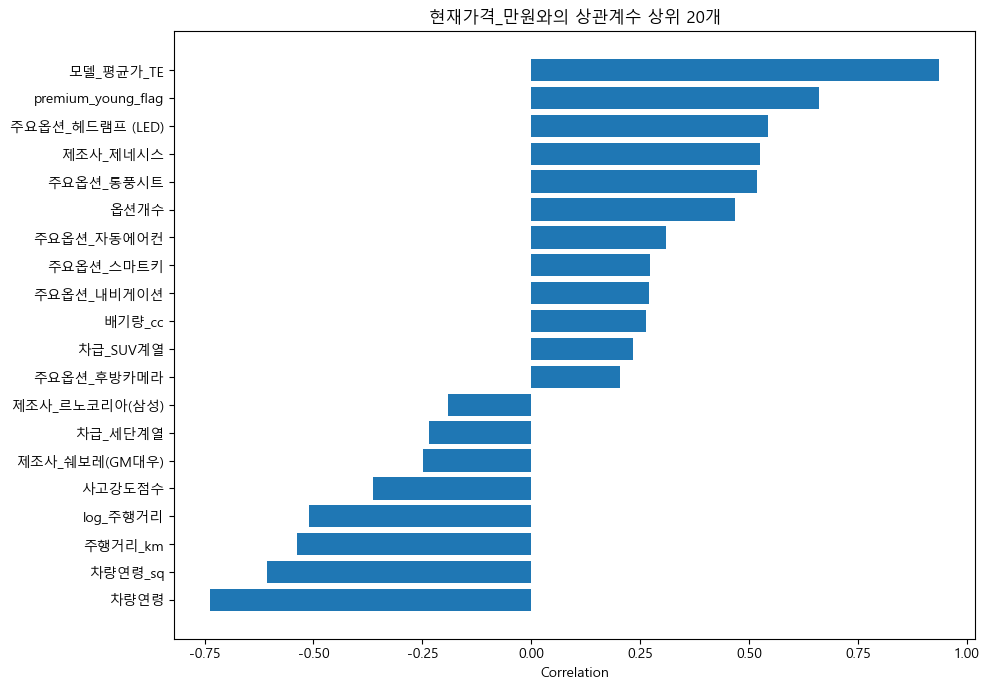

,corr_with_target
모델_평균가_TE,0.936266
차량연령,-0.736542
premium_young_flag,0.661322
차량연령_sq,-0.606436
주요옵션_헤드램프 (LED),0.543473
주행거리_km,-0.538083
제조사_제네시스,0.525056
주요옵션_통풍시트,0.519069
log_주행거리,-0.509203
옵션개수,0.467687


In [14]:
numeric_cols = df_model_base.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = (
    df_model_base[numeric_cols]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

top_corr = corr_with_target.head(20).sort_values()

plt.figure(figsize=(10, 7))
plt.barh(top_corr.index, top_corr.values)
plt.title(f"{TARGET}와의 상관계수 상위 20개")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

display(corr_with_target.head(20).rename("corr_with_target").to_frame())


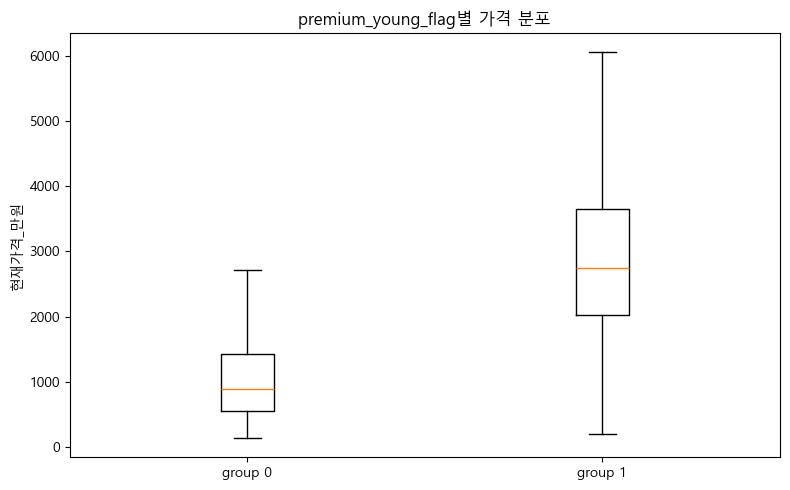

,count,mean,median,std,min,max
premium_young_flag,,,,,,
0,5796,1049.71,890.0,652.77,140.0,4650.0
1,5528,2963.36,2742.5,1401.79,199.0,12590.0


In [15]:
if "premium_young_flag" in df_model_base.columns:
    plot_df = df_model_base[[TARGET, "premium_young_flag"]].copy()

    group0 = plot_df.loc[plot_df["premium_young_flag"] == 0, TARGET].dropna()
    group1 = plot_df.loc[plot_df["premium_young_flag"] == 1, TARGET].dropna()

    plt.figure(figsize=(8, 5))
    plt.boxplot([group0, group1], labels=["group 0", "group 1"], showfliers=False)
    plt.title("premium_young_flag별 가격 분포")
    plt.ylabel(TARGET)
    plt.tight_layout()
    plt.show()

    display(
        plot_df.groupby("premium_young_flag")[TARGET]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .round(2)
    )


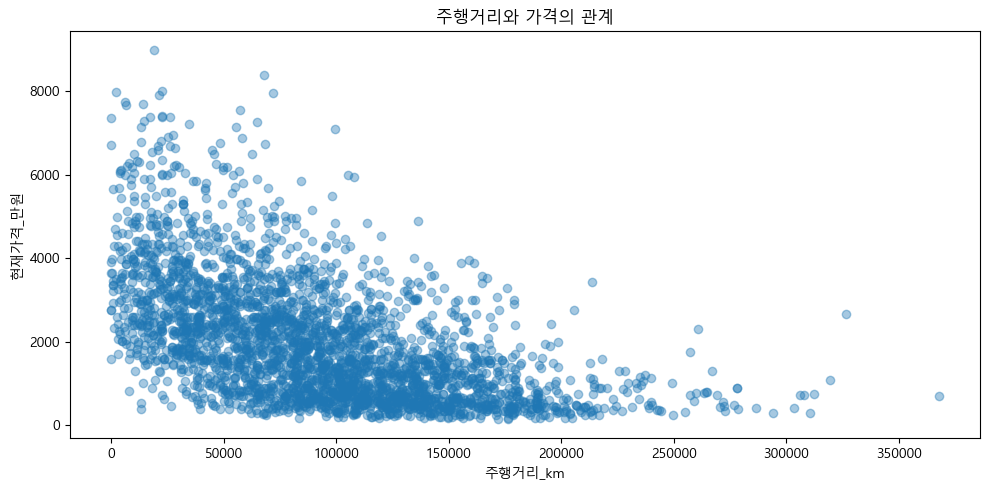

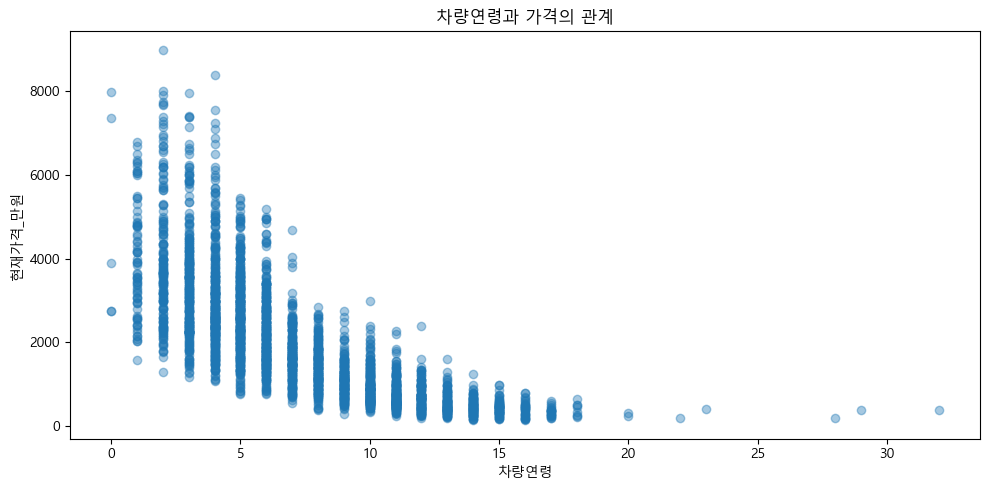

In [16]:
sample_n = min(len(df_model_base), 3000)
sample_df = df_model_base.sample(sample_n, random_state=RANDOM_STATE) if len(df_model_base) > sample_n else df_model_base.copy()

if {"주행거리_km", TARGET}.issubset(sample_df.columns):
    plt.figure(figsize=(10, 5))
    plt.scatter(sample_df["주행거리_km"], sample_df[TARGET], alpha=0.4)
    plt.title("주행거리와 가격의 관계")
    plt.xlabel("주행거리_km")
    plt.ylabel(TARGET)
    plt.tight_layout()
    plt.show()

if {"차량연령", TARGET}.issubset(sample_df.columns):
    plt.figure(figsize=(10, 5))
    plt.scatter(sample_df["차량연령"], sample_df[TARGET], alpha=0.4)
    plt.title("차량연령과 가격의 관계")
    plt.xlabel("차량연령")
    plt.ylabel(TARGET)
    plt.tight_layout()
    plt.show()


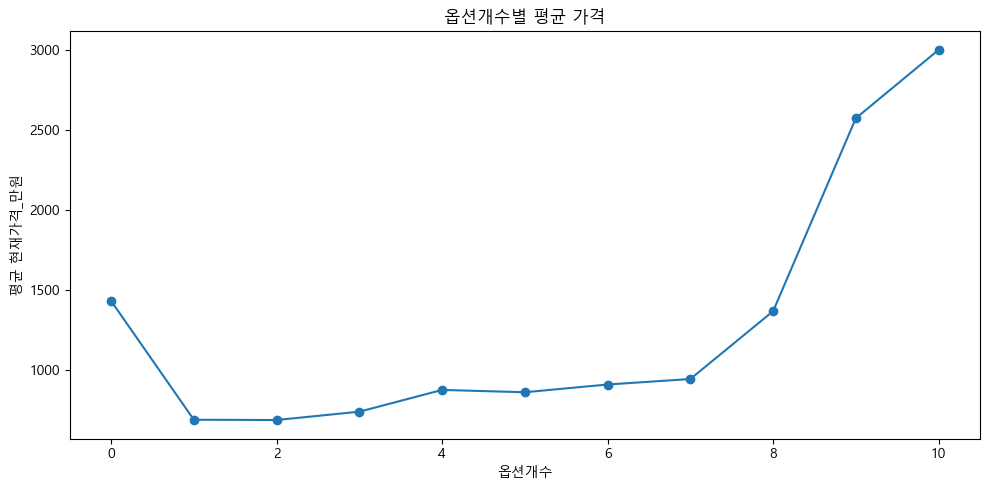

,옵션개수,count,mean,median
0,0,234,1433.068376,999.0
1,1,47,692.255319,465.0
2,2,88,690.556818,490.0
3,3,192,742.473958,500.0
4,4,289,878.190311,590.0
5,5,641,863.750390,633.0
6,6,867,911.891580,750.0
7,7,1096,946.189781,790.0
8,8,1575,1369.256508,1350.0
9,9,4162,2572.475012,2432.0


In [17]:
if {"옵션개수", TARGET}.issubset(df_model_base.columns):
    option_agg = (
        df_model_base.groupby("옵션개수")[TARGET]
        .agg(["count", "mean", "median"])
        .reset_index()
        .sort_values("옵션개수")
    )

    plt.figure(figsize=(10, 5))
    plt.plot(option_agg["옵션개수"], option_agg["mean"], marker="o")
    plt.title("옵션개수별 평균 가격")
    plt.xlabel("옵션개수")
    plt.ylabel(f"평균 {TARGET}")
    plt.tight_layout()
    plt.show()

    display(option_agg.head(20))


# 6. 5-Fold OOF + 그룹 분리 CatBoost 검증
핵심 포인트는 아래와 같습니다.

1. **Outer KFold**로 성능을 검증  
2. 각 fold 안에서 **OOF Target Encoding** 생성  
3. `premium_young_flag` 기준으로 그룹을 나눠서 별도 모델 학습  
4. 예측값을 다시 합쳐서 전체 OOF 성능 계산  

즉, 이 구조는  
**“그룹 분리 + leakage를 줄인 TE + CatBoost”** 조합이라고 볼 수 있습니다.


In [18]:
def fit_catboost_model(X_train, y_train, X_valid, y_valid, cat_cols, params):
    model = CatBoostRegressor(
        loss_function="MAE",
        eval_metric="MAE",
        random_seed=RANDOM_STATE,
        od_type="Iter",
        od_wait=300,
        verbose=0,
        **params
    )
    model.fit(
        X_train,
        y_train,
        cat_features=cat_cols,
        eval_set=(X_valid, y_valid),
        use_best_model=True
    )
    pred = model.predict(X_valid)
    return model, pred


def run_grouped_cv(df_input: pd.DataFrame, n_splits: int = 5):
    df_work = add_features(df_input.copy())

    if TARGET not in df_work.columns:
        raise KeyError(
            f"타깃 컬럼 `{TARGET}` 이(가) 없습니다. 현재 컬럼 예시: {df_work.columns[:15].tolist()}"
        )

    drop_feature_only_cols = ["매물ID", "모델_평균가_TE", "flag_special_price"]
    df_work = df_work.drop(columns=[c for c in drop_feature_only_cols if c in df_work.columns]).copy()

    outer_kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    oof_pred_series = pd.Series(index=df_work.index, dtype=float)
    fold_rows = []
    best_iter_rows = []
    oof_feature_snapshots = []

    for fold, (tr_idx, val_idx) in enumerate(outer_kf.split(df_work), start=1):
        train_fold = df_work.iloc[tr_idx].copy()
        valid_fold = df_work.iloc[val_idx].copy()

        pred_fold = pd.Series(index=valid_fold.index, dtype=float)

        for g in [0, 1]:
            train_g = train_fold[train_fold["premium_young_flag"] == g].copy()
            valid_g = valid_fold[valid_fold["premium_young_flag"] == g].copy()

            if len(valid_g) == 0 or len(train_g) == 0:
                continue

            y_tr = train_g[TARGET].copy()
            y_val = valid_g[TARGET].copy()

            train_g["모델_TE_OOF"], valid_g["모델_TE_OOF"] = add_oof_te(
                train_g, valid_g, col="모델", target=TARGET, random_state=RANDOM_STATE
            )
            train_g["모델_연식구간_TE_OOF"], valid_g["모델_연식구간_TE_OOF"] = add_oof_te(
                train_g, valid_g, col="모델_연식구간", target=TARGET, random_state=RANDOM_STATE
            )
            train_g["모델_연료_TE_OOF"], valid_g["모델_연료_TE_OOF"] = add_oof_te(
                train_g, valid_g, col="모델_연료", target=TARGET, random_state=RANDOM_STATE
            )

            X_tr = train_g.drop(columns=[TARGET]).copy()
            X_val = valid_g.drop(columns=[TARGET]).copy()

            cat_cols = X_tr.select_dtypes(include=["object", "category"]).columns.tolist()
            params = get_group_params(g)

            model, pred = fit_catboost_model(X_tr, y_tr, X_val, y_val, cat_cols, params)
            pred_fold.loc[valid_g.index] = pred

            best_iter_rows.append({
                "fold": fold,
                "group": g,
                "train_n": len(train_g),
                "valid_n": len(valid_g),
                "best_iteration": model.get_best_iteration()
            })

            snapshot_cols = [
                c for c in ["모델", "차량연령", "주행거리_km", "사고강도점수", "premium_young_flag"]
                if c in valid_g.columns
            ]
            snap = valid_g[snapshot_cols].copy()
            snap["fold"] = fold
            snap["group"] = g
            snap["actual"] = y_val.values
            snap["pred"] = pred
            oof_feature_snapshots.append(snap)

        valid_mask = pred_fold.notna()

        if valid_mask.sum() == 0:
            raise ValueError(f"{fold}번째 fold에서 유효한 예측값이 생성되지 않았습니다.")

        y_val_total = valid_fold.loc[valid_mask, TARGET].copy()
        pred_val_total = pred_fold.loc[valid_mask].copy()

        fold_mae = mean_absolute_error(y_val_total, pred_val_total)
        fold_rmse = np.sqrt(mean_squared_error(y_val_total, pred_val_total))
        fold_r2 = r2_score(y_val_total, pred_val_total)

        fold_rows.append({
            "fold": fold,
            "eval_n": int(valid_mask.sum()),
            "coverage_pct": round(valid_mask.mean() * 100, 2),
            "MAE": fold_mae,
            "RMSE": fold_rmse,
            "R2": fold_r2
        })

        oof_pred_series.loc[pred_val_total.index] = pred_val_total.values

    fold_result = pd.DataFrame(fold_rows)
    best_iter_df = pd.DataFrame(best_iter_rows)

    oof_df = pd.concat(oof_feature_snapshots, axis=0).sort_index()
    oof_df = oof_df[oof_df["pred"].notna()].copy()
    oof_df["abs_err"] = (oof_df["actual"] - oof_df["pred"]).abs()
    oof_df["pct_err"] = oof_df["abs_err"] / oof_df["actual"].clip(lower=1) * 100
    oof_df["residual"] = oof_df["actual"] - oof_df["pred"]

    summary = pd.DataFrame([{
        "OOF_n": len(oof_df),
        "OOF_MAE": mean_absolute_error(oof_df["actual"], oof_df["pred"]),
        "OOF_RMSE": np.sqrt(mean_squared_error(oof_df["actual"], oof_df["pred"])),
        "OOF_R2": r2_score(oof_df["actual"], oof_df["pred"]),
        "Fold_MAE_mean": fold_result["MAE"].mean(),
        "Fold_MAE_std": fold_result["MAE"].std(),
        "Coverage_pct_mean": fold_result["coverage_pct"].mean()
    }]).round(4)

    return {
        "fold_result": fold_result.round(4),
        "best_iter_df": best_iter_df,
        "oof_df": oof_df,
        "summary": summary,
        "oof_pred_series": oof_pred_series
    }


In [19]:
cv_result = run_grouped_cv(df_clean, n_splits=N_SPLITS)

display(Markdown("### CV 요약"))
display(cv_result["summary"])

display(Markdown("### Fold별 성능"))
display(cv_result["fold_result"])

display(Markdown("### 그룹별 best iteration"))
display(cv_result["best_iter_df"])


### CV 요약

,OOF_n,OOF_MAE,OOF_RMSE,OOF_R2,Fold_MAE_mean,Fold_MAE_std,Coverage_pct_mean
0,11324,171.8567,307.2483,0.9549,171.8569,4.9119,100.0


### Fold별 성능

,fold,eval_n,coverage_pct,MAE,RMSE,R2
0,1,2265,100.0,172.4508,298.8909,0.9563
1,2,2265,100.0,165.0543,294.8156,0.9587
2,3,2265,100.0,178.1079,320.7177,0.9521
3,4,2265,100.0,169.5118,310.5871,0.9537
4,5,2264,100.0,174.1598,310.5353,0.9536


### 그룹별 best iteration

,fold,group,train_n,valid_n,best_iteration
0,1,0,4627,1169,4393
1,1,1,4432,1096,4999
2,2,0,4604,1192,3711
3,2,1,4455,1073,4994
4,3,0,4637,1159,4902
5,3,1,4422,1106,4962
6,4,0,4663,1133,3227
7,4,1,4396,1132,4995
8,5,0,4653,1143,4955
9,5,1,4407,1121,4998


In [20]:
summary_row = cv_result["summary"].iloc[0]

html = f'''
<div style="display:flex; gap:12px; flex-wrap:wrap;">
  <div style="padding:14px 18px; border:1px solid #d9d9d9; border-radius:12px; min-width:180px;">
    <div style="font-size:13px; color:#666;">OOF MAE</div>
    <div style="font-size:28px; font-weight:700;">{summary_row["OOF_MAE"]:.2f}</div>
  </div>
  <div style="padding:14px 18px; border:1px solid #d9d9d9; border-radius:12px; min-width:180px;">
    <div style="font-size:13px; color:#666;">OOF RMSE</div>
    <div style="font-size:28px; font-weight:700;">{summary_row["OOF_RMSE"]:.2f}</div>
  </div>
  <div style="padding:14px 18px; border:1px solid #d9d9d9; border-radius:12px; min-width:180px;">
    <div style="font-size:13px; color:#666;">OOF R²</div>
    <div style="font-size:28px; font-weight:700;">{summary_row["OOF_R2"]:.4f}</div>
  </div>
  <div style="padding:14px 18px; border:1px solid #d9d9d9; border-radius:12px; min-width:180px;">
    <div style="font-size:13px; color:#666;">Fold MAE Std</div>
    <div style="font-size:28px; font-weight:700;">{summary_row["Fold_MAE_std"]:.2f}</div>
  </div>
</div>
'''
display(HTML(html))


# 7. OOF 결과 시각화 및 잔차 분석
이 섹션은 발표에서 꽤 강합니다.  
“모델이 평균적으로 맞는다”를 넘어서 **어디서 틀리는지**를 보여줄 수 있기 때문입니다.


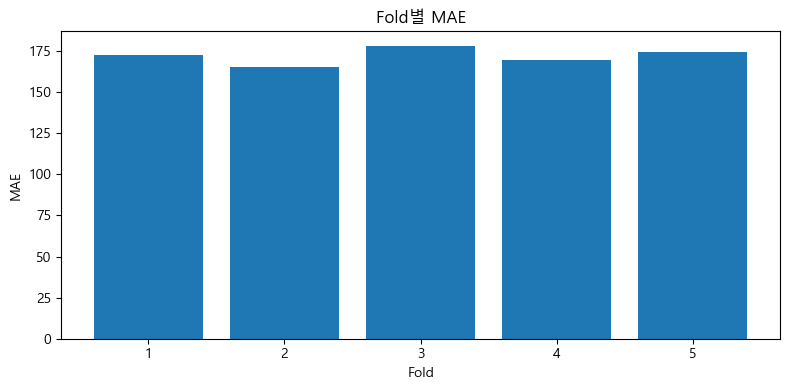

In [21]:
fold_plot = cv_result["fold_result"].copy()

plt.figure(figsize=(8, 4))
plt.bar(fold_plot["fold"].astype(str), fold_plot["MAE"])
plt.title("Fold별 MAE")
plt.xlabel("Fold")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()


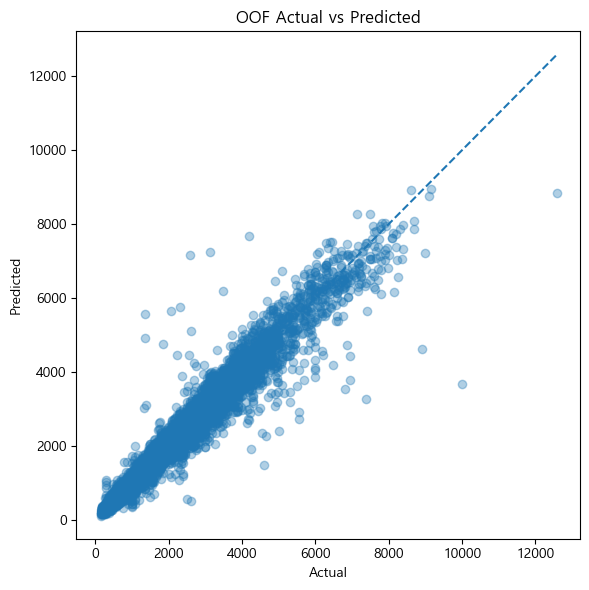

In [22]:
oof_df = cv_result["oof_df"].copy()

plt.figure(figsize=(6, 6))
plt.scatter(oof_df["actual"], oof_df["pred"], alpha=0.35)
min_v = min(oof_df["actual"].min(), oof_df["pred"].min())
max_v = max(oof_df["actual"].max(), oof_df["pred"].max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.title("OOF Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()


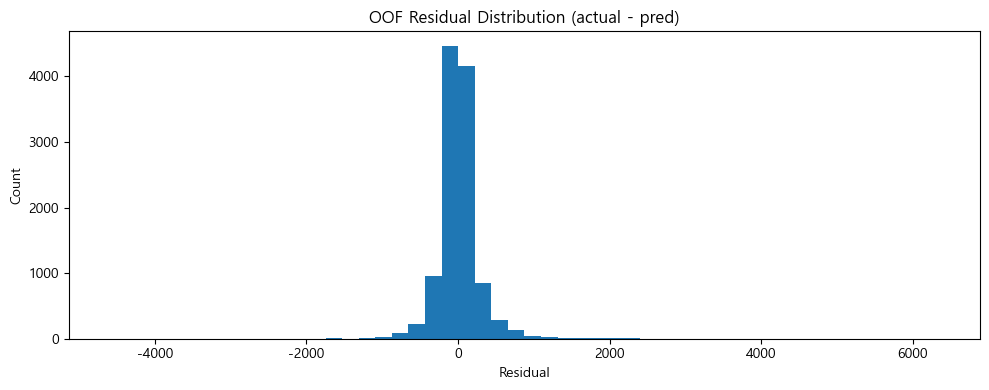

In [23]:
plt.figure(figsize=(10, 4))
plt.hist(oof_df["residual"], bins=50)
plt.title("OOF Residual Distribution (actual - pred)")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


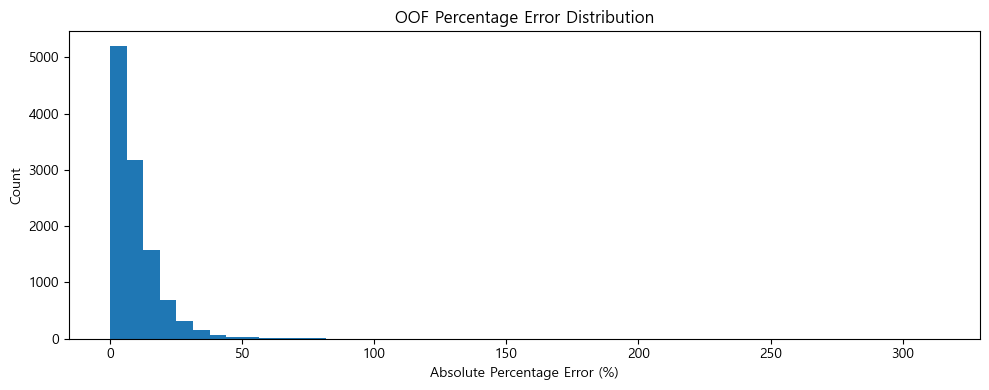

In [24]:
plt.figure(figsize=(10, 4))
plt.hist(oof_df["pct_err"], bins=50)
plt.title("OOF Percentage Error Distribution")
plt.xlabel("Absolute Percentage Error (%)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


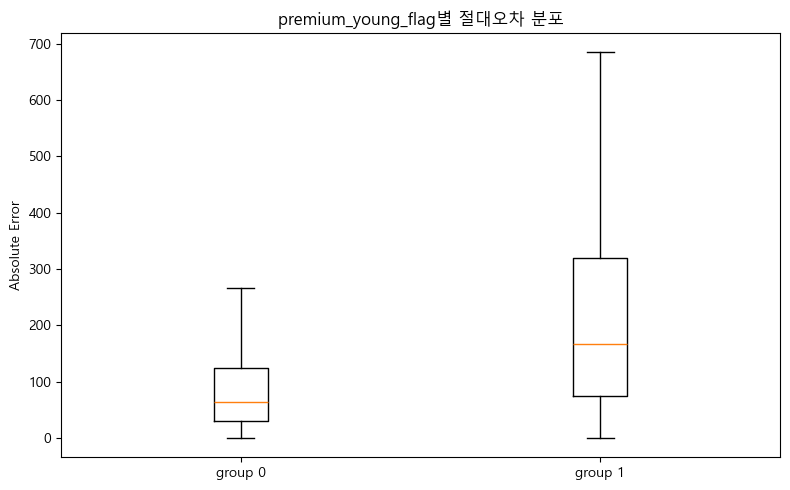

,mean_abs_err,mean_pct_err
premium_young_flag,,
0,98.06,10.50
1,249.23,9.04


In [25]:
if "premium_young_flag" in oof_df.columns:
    group0 = oof_df.loc[oof_df["premium_young_flag"] == 0, "abs_err"].dropna()
    group1 = oof_df.loc[oof_df["premium_young_flag"] == 1, "abs_err"].dropna()

    plt.figure(figsize=(8, 5))
    plt.boxplot([group0, group1], labels=["group 0", "group 1"], showfliers=False)
    plt.title("premium_young_flag별 절대오차 분포")
    plt.ylabel("Absolute Error")
    plt.tight_layout()
    plt.show()

    display(
        oof_df.groupby("premium_young_flag")[["abs_err", "pct_err"]]
        .mean()
        .round(2)
        .rename(columns={"abs_err": "mean_abs_err", "pct_err": "mean_pct_err"})
    )


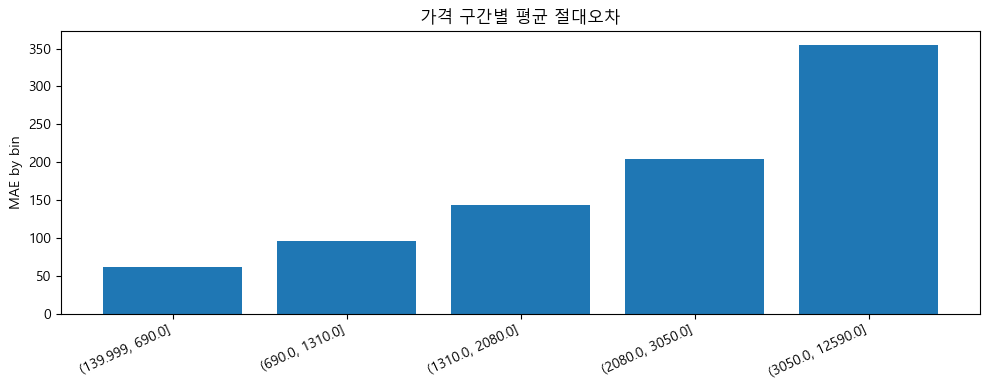

,price_bin,abs_err
0,"(139.999, 690.0]",60.994936
1,"(690.0, 1310.0]",96.525981
2,"(1310.0, 2080.0]",143.033517
3,"(2080.0, 3050.0]",204.493168
4,"(3050.0, 12590.0]",355.008880


In [26]:
oof_df["price_bin"] = pd.qcut(oof_df["actual"], q=5, duplicates="drop")
price_bin_mae = (
    oof_df.groupby("price_bin", observed=False)["abs_err"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 4))
plt.bar(price_bin_mae["price_bin"].astype(str), price_bin_mae["abs_err"])
plt.xticks(rotation=25, ha="right")
plt.title("가격 구간별 평균 절대오차")
plt.ylabel("MAE by bin")
plt.tight_layout()
plt.show()

display(price_bin_mae)


### premium_young_flag별 평균 오차

,premium_young_flag,abs_err,pct_err
0,1,249.23,9.04
1,0,98.06,10.50


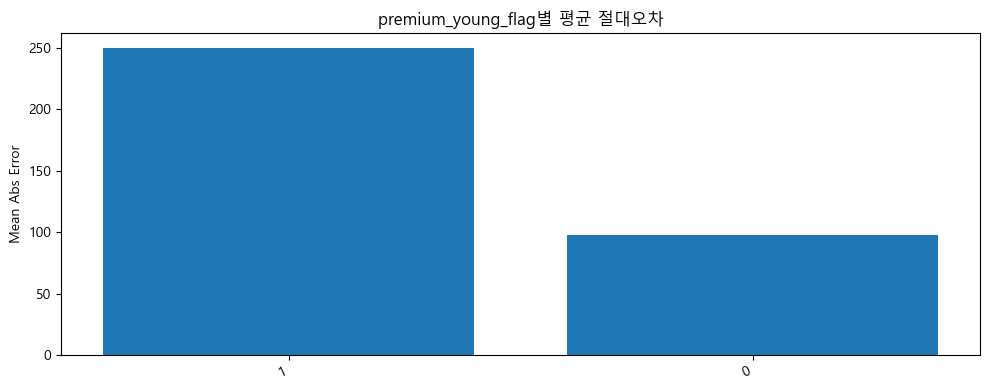

In [27]:
group_cols = [c for c in ["사고강도_bin", "연식구간", "premium_young_flag"] if c in oof_df.columns]

for col in group_cols:
    stat_df = (
        oof_df.groupby(col)[["abs_err", "pct_err"]]
        .mean()
        .round(2)
        .sort_values("abs_err", ascending=False)
        .reset_index()
    )
    display(Markdown(f"### {col}별 평균 오차"))
    display(stat_df)

    plt.figure(figsize=(10, 4))
    plt.bar(stat_df[col].astype(str), stat_df["abs_err"])
    plt.title(f"{col}별 평균 절대오차")
    plt.ylabel("Mean Abs Error")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()


In [28]:
display(Markdown("### 오차가 큰 샘플 Top 30"))
display(
    oof_df.sort_values("abs_err", ascending=False)
          .head(30)
          .reset_index(drop=True)
)


### 오차가 큰 샘플 Top 30

,모델,차량연령,주행거리_km,사고강도점수,premium_young_flag,fold,group,actual,pred,abs_err,pct_err,residual,price_bin
0,G80 (RG3),5,60519,2,1,4,1,9998.0,3658.775543,6339.224457,63.404926,6339.224457,"(3050.0, 12590.0]"
1,G90 (RS4),4,57635,2,1,5,1,2574.0,7161.923130,4587.923130,178.240992,-4587.923130,"(2080.0, 3050.0]"
2,일렉트리파이드 G80 (RG3),1,22700,2,1,2,1,8904.0,4628.560795,4275.439205,48.017062,4275.439205,"(3050.0, 12590.0]"
3,G80 (RG3),2,32567,2,1,4,1,1344.0,5558.937543,4214.937543,313.611424,-4214.937543,"(1310.0, 2080.0]"
4,스타리아,3,17271,1,1,1,1,7390.0,3249.987872,4140.012128,56.021815,4140.012128,"(3050.0, 12590.0]"
5,G90 (RS4),3,44406,2,1,1,1,3120.0,7253.715186,4133.715186,132.490871,-4133.715186,"(3050.0, 12590.0]"
6,G90 (RS4),2,15918,0,1,5,1,12590.0,8836.133102,3753.866898,29.816258,3753.866898,"(3050.0, 12590.0]"
7,G80 (RG3),3,41959,0,1,3,1,1351.0,4925.312784,3574.312784,264.567934,-3574.312784,"(1310.0, 2080.0]"
8,일렉트리파이드 GV70,4,52192,2,1,3,1,2064.0,5636.805991,3572.805991,173.101065,-3572.805991,"(1310.0, 2080.0]"
9,G90 (RS4),3,20954,2,1,4,1,4176.0,7683.749540,3507.749540,83.997834,-3507.749540,"(3050.0, 12590.0]"


# 8. 최종 모델 재학습 및 서비스용 아티팩트 생성
여기서는 전체 데이터를 사용해 그룹별 최종 모델을 학습하고,  
가격 범위 추천을 위한 **잔차 기반 구간(calibration band)** 도 함께 만듭니다.


In [29]:
def prepare_group_full_train(df_group: pd.DataFrame):
    df_group = df_group.copy()

    te_model = build_te_mapping(df_group, "모델", TARGET)
    te_model_age = build_te_mapping(df_group, "모델_연식구간", TARGET)
    te_model_fuel = build_te_mapping(df_group, "모델_연료", TARGET)

    df_group = apply_te_mapping(df_group, "모델", te_model, "모델_TE")
    df_group = apply_te_mapping(df_group, "모델_연식구간", te_model_age, "모델_연식구간_TE")
    df_group = apply_te_mapping(df_group, "모델_연료", te_model_fuel, "모델_연료_TE")

    drop_cols = [TARGET, "매물ID", "모델_평균가_TE", "flag_special_price"]
    X = df_group.drop(columns=[c for c in drop_cols if c in df_group.columns]).copy()
    y = df_group[TARGET].copy()
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

    return X, y, cat_cols, {
        "모델": te_model,
        "모델_연식구간": te_model_age,
        "모델_연료": te_model_fuel
    }


def apply_group_artifacts(df_group: pd.DataFrame, artifacts: dict):
    df_group = df_group.copy()

    df_group = apply_te_mapping(df_group, "모델", artifacts["te_maps"]["모델"], "모델_TE")
    df_group = apply_te_mapping(df_group, "모델_연식구간", artifacts["te_maps"]["모델_연식구간"], "모델_연식구간_TE")
    df_group = apply_te_mapping(df_group, "모델_연료", artifacts["te_maps"]["모델_연료"], "모델_연료_TE")

    feature_cols = artifacts["feature_cols"]

    for col in feature_cols:
        if col not in df_group.columns:
            df_group[col] = "unknown" if col in artifacts["cat_cols"] else 0

    X = df_group[feature_cols].copy()

    for c in artifacts["cat_cols"]:
        X[c] = X[c].astype(str)

    return X


def train_price_system(df_input: pd.DataFrame):
    df_all = add_features(df_input.copy())

    if TARGET not in df_all.columns:
        raise KeyError(f"타깃 컬럼 `{TARGET}` 이(가) 없습니다.")

    outer_kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    oof_pred_series = pd.Series(index=df_all.index, dtype=float)

    for _, (tr_idx, val_idx) in enumerate(outer_kf.split(df_all), start=1):
        train_fold = df_all.iloc[tr_idx].copy()
        valid_fold = df_all.iloc[val_idx].copy()

        pred_fold = pd.Series(index=valid_fold.index, dtype=float)

        for g in [0, 1]:
            train_g = train_fold[train_fold["premium_young_flag"] == g].copy()
            valid_g = valid_fold[valid_fold["premium_young_flag"] == g].copy()

            if len(train_g) == 0 or len(valid_g) == 0:
                continue

            y_tr = train_g[TARGET].copy()
            y_val = valid_g[TARGET].copy()

            train_g["모델_TE_OOF"], valid_g["모델_TE_OOF"] = add_oof_te(
                train_g, valid_g, col="모델", target=TARGET, random_state=RANDOM_STATE
            )
            train_g["모델_연식구간_TE_OOF"], valid_g["모델_연식구간_TE_OOF"] = add_oof_te(
                train_g, valid_g, col="모델_연식구간", target=TARGET, random_state=RANDOM_STATE
            )
            train_g["모델_연료_TE_OOF"], valid_g["모델_연료_TE_OOF"] = add_oof_te(
                train_g, valid_g, col="모델_연료", target=TARGET, random_state=RANDOM_STATE
            )

            drop_cols = [TARGET, "매물ID", "모델_평균가_TE", "flag_special_price"]
            X_tr = train_g.drop(columns=[c for c in drop_cols if c in train_g.columns]).copy()
            X_val = valid_g.drop(columns=[c for c in drop_cols if c in valid_g.columns]).copy()

            cat_cols = X_tr.select_dtypes(include=["object", "category"]).columns.tolist()
            params = get_group_params(g)
            _, pred = fit_catboost_model(X_tr, y_tr, X_val, y_val, cat_cols, params)

            pred_fold.loc[valid_g.index] = pred

        oof_pred_series.loc[pred_fold.dropna().index] = pred_fold.dropna().values

    calib = df_all.copy()
    calib["pred"] = oof_pred_series
    calib = calib[calib["pred"].notna()].copy()
    calib["resid_ratio"] = (calib[TARGET] - calib["pred"]) / calib["pred"].clip(lower=1)

    band_table = calib.groupby("premium_young_flag")["resid_ratio"].quantile([0.2, 0.8]).unstack()
    band_table.columns = ["q20_resid", "q80_resid"]

    group_artifacts = {}

    for g in [0, 1]:
        df_g = df_all[df_all["premium_young_flag"] == g].copy()

        if len(df_g) == 0:
            continue

        X_g, y_g, cat_cols_g, te_maps_g = prepare_group_full_train(df_g)
        params = get_group_params(g)

        final_model = CatBoostRegressor(
            loss_function="MAE",
            eval_metric="MAE",
            random_seed=RANDOM_STATE,
            verbose=0,
            **params
        )
        final_model.fit(X_g, y_g, cat_features=cat_cols_g)

        group_artifacts[g] = {
            "model": final_model,
            "te_maps": te_maps_g,
            "feature_cols": X_g.columns.tolist(),
            "cat_cols": cat_cols_g,
            "params": params,
            "train_n": len(df_g)
        }

    artifacts = {
        "band_table": band_table,
        "group_artifacts": group_artifacts,
        "target": TARGET
    }

    return artifacts


In [30]:
artifacts = train_price_system(df_clean)

display(Markdown("### Calibration band"))
display(artifacts["band_table"])

final_feature_rows = []
for g, info in artifacts["group_artifacts"].items():
    for col in info["feature_cols"]:
        final_feature_rows.append({
            "group": g,
            "feature": col,
            "is_cat": col in info["cat_cols"]
        })

final_feature_df = pd.DataFrame(final_feature_rows)
display(Markdown("### 그룹별 최종 입력 피처"))
display(final_feature_df)


### Calibration band

,q20_resid,q80_resid
premium_young_flag,,
0,-0.094144,0.102087
1,-0.077997,0.086058


### 그룹별 최종 입력 피처

,group,feature,is_cat
0,0,모델,True
1,0,주행거리_km,False
2,0,배기량_cc,False
3,0,좌석수,False
4,0,차량연령,False
...,...,...,...
107,1,모델_연료,True
108,1,premium_young_flag,False
109,1,모델_TE,False
110,1,모델_연식구간_TE,False


# 9. 그룹별 Feature Importance
이 부분은 모델이 실제로 무엇을 크게 보고 있는지 설명하는 데 매우 유용합니다.  
CatBoost의 `PredictionValuesChange` 중요도를 사용합니다.


In [31]:
def plot_feature_importance_for_group(artifacts: dict, group_flag: int, top_n: int = 20):
    info = artifacts["group_artifacts"][group_flag]
    model = info["model"]
    feature_cols = info["feature_cols"]

    importance = model.get_feature_importance(type="PredictionValuesChange")
    imp_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": importance
    }).sort_values("importance", ascending=False).head(top_n).sort_values("importance")

    plt.figure(figsize=(10, max(5, top_n * 0.35)))
    plt.barh(imp_df["feature"], imp_df["importance"])
    plt.title(f"group {group_flag} Feature Importance Top {top_n}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    return imp_df.sort_values("importance", ascending=False).reset_index(drop=True)


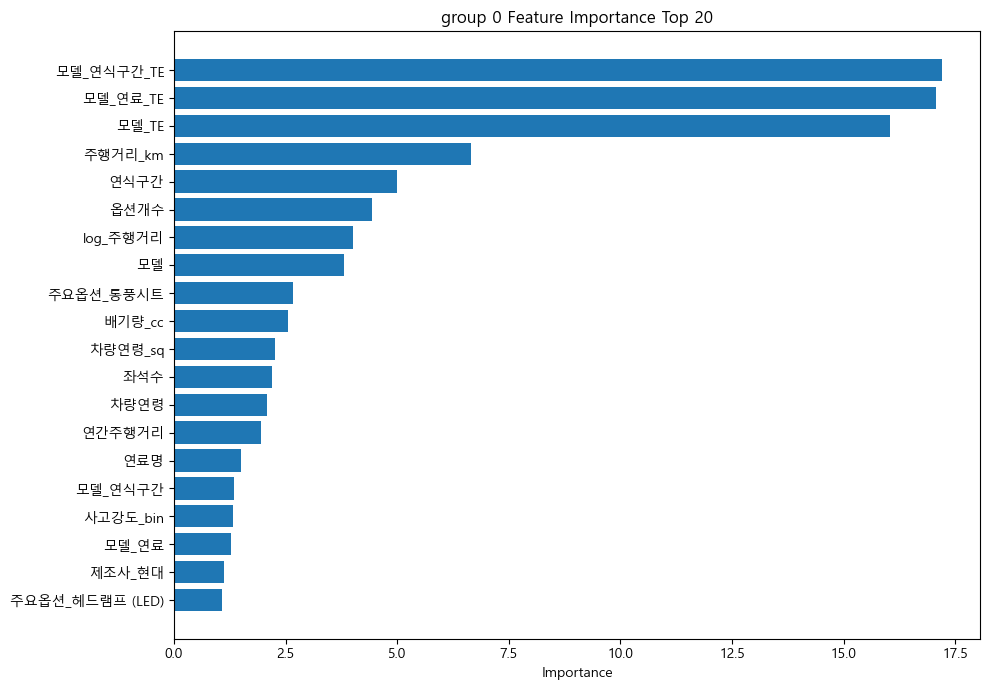

### group 0 중요도

,feature,importance
0,모델_연식구간_TE,17.192935
1,모델_연료_TE,17.064502
2,모델_TE,16.026030
3,주행거리_km,6.647579
4,연식구간,5.004970
5,옵션개수,4.435280
6,log_주행거리,4.005317
7,모델,3.818475
8,주요옵션_통풍시트,2.674035
9,배기량_cc,2.563988


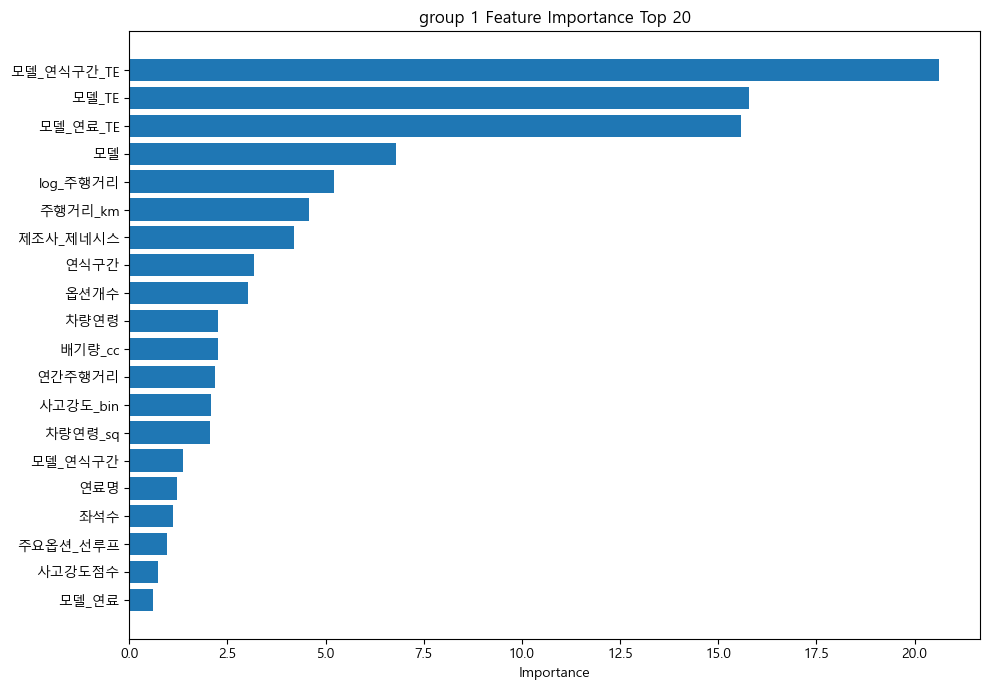

### group 1 중요도

,feature,importance
0,모델_연식구간_TE,20.635185
1,모델_TE,15.795439
2,모델_연료_TE,15.568768
3,모델,6.801074
4,log_주행거리,5.200318
5,주행거리_km,4.578428
6,제조사_제네시스,4.196818
7,연식구간,3.168962
8,옵션개수,3.033369
9,차량연령,2.267377


In [32]:
imp_g0 = plot_feature_importance_for_group(artifacts, group_flag=0, top_n=20)
display(Markdown("### group 0 중요도"))
display(imp_g0)

imp_g1 = plot_feature_importance_for_group(artifacts, group_flag=1, top_n=20)
display(Markdown("### group 1 중요도"))
display(imp_g1)


## 선택: SHAP 시각화
아래 셀은 환경에 따라 시간이 조금 걸릴 수 있습니다.  
발표 자료에 더 깊이 있는 설명이 필요할 때 사용하세요.


In [33]:
# 선택 실행 셀
# group 0 / group 1 각각 샘플 500건으로 SHAP 값 계산
# CatBoost가 설치된 환경에서는 보통 동작합니다.

def run_optional_shap_summary(df_input: pd.DataFrame, artifacts: dict, group_flag: int, sample_size: int = 500):
    df_work = add_features(df_input.copy())
    df_work = df_work[df_work["premium_young_flag"] == group_flag].copy()

    if len(df_work) == 0:
        print(f"group {group_flag} 데이터가 없습니다.")
        return None

    info = artifacts["group_artifacts"][group_flag]
    df_work = apply_group_artifacts(df_work, info)

    if len(df_work) > sample_size:
        df_work = df_work.sample(sample_size, random_state=RANDOM_STATE)

    pool = Pool(df_work, cat_features=info["cat_cols"])
    shap_values = info["model"].get_feature_importance(pool, type="ShapValues")

    shap_df = pd.DataFrame(
        np.abs(shap_values[:, :-1]).mean(axis=0),
        index=info["feature_cols"],
        columns=["mean_abs_shap"]
    ).sort_values("mean_abs_shap", ascending=False)

    top_df = shap_df.head(20).sort_values("mean_abs_shap")

    plt.figure(figsize=(10, 7))
    plt.barh(top_df.index, top_df["mean_abs_shap"])
    plt.title(f"group {group_flag} Mean |SHAP| Top 20")
    plt.xlabel("Mean Absolute SHAP")
    plt.tight_layout()
    plt.show()

    return shap_df

# 예시 실행
# shap_g0 = run_optional_shap_summary(df_clean, artifacts, group_flag=0)
# shap_g1 = run_optional_shap_summary(df_clean, artifacts, group_flag=1)


# 10. 서비스용 예측 함수
아래 함수는 새 차량 정보가 들어왔을 때 다음 3가지를 반환합니다.

- `빠른판매가`
- `추천판매가`
- `상단희망가`

즉, 하나의 점 추정값이 아니라 **가격 범위 중심 UX**에 맞춰서 결과를 보여주는 형태입니다.


In [34]:
def predict_price_range(new_data, artifacts: dict) -> pd.DataFrame:
    if isinstance(new_data, dict):
        new_df = pd.DataFrame([new_data])
    elif isinstance(new_data, pd.Series):
        new_df = pd.DataFrame([new_data.to_dict()])
    else:
        new_df = new_data.copy()

    new_df = add_features(new_df)

    result = new_df.copy()
    result["추천판매가"] = np.nan
    result["빠른판매가"] = np.nan
    result["상단희망가"] = np.nan

    band_table = artifacts["band_table"]
    group_artifacts = artifacts["group_artifacts"]

    for g in [0, 1]:
        idx = result["premium_young_flag"] == g
        if idx.sum() == 0:
            continue

        part = result.loc[idx].copy()
        X_part = apply_group_artifacts(part, group_artifacts[g])
        pred = group_artifacts[g]["model"].predict(X_part)

        q20_resid = band_table.loc[g, "q20_resid"]
        q80_resid = band_table.loc[g, "q80_resid"]

        lower = np.maximum(pred * (1 + q20_resid), 0)
        upper = np.maximum(pred * (1 + q80_resid), 0)

        lower = np.minimum(lower, upper)
        upper = np.maximum(lower, upper)

        result.loc[idx, "추천판매가"] = pred
        result.loc[idx, "빠른판매가"] = lower
        result.loc[idx, "상단희망가"] = upper

    for col in ["빠른판매가", "추천판매가", "상단희가"] if False else []:
        pass

    result["빠른판매가"] = result["빠른판매가"].round(0)
    result["추천판매가"] = result["추천판매가"].round(0)
    result["상단희망가"] = result["상단희망가"].round(0)

    show_cols = [c for c in [
        "모델", "차량연령", "주행거리_km", "배기량_cc", "사고강도점수",
        "premium_young_flag", "빠른판매가", "추천판매가", "상단희망가"
    ] if c in result.columns]

    return result[show_cols]


In [35]:
sample_car = {
    "모델": "더 뉴 카니발 4세대",
    "주행거리_km": 32000,
    "배기량_cc": 2200,
    "좌석수": 9,
    "차량연령": 2,
    "사고강도점수": 1,

    "주요옵션_선루프": 0,
    "주요옵션_헤드램프_(LED)": 1,
    "주요옵션_주차감지센서": 1,
    "주요옵션_후방카메라": 1,
    "주요옵션_자동에어컨": 1,
    "주요옵션_스마트키": 1,
    "주요옵션_내비게이션": 1,
    "주요옵션_열선시트": 1,
    "주요옵션_통풍시트": 1,
    "주요옵션_가죽시트": 1,

    "제조사_현대": 0,
    "제조사_기아": 1,
    "제조사_제네시스": 0,
    "제조사_KG모빌리티(쌍용)": 0,
    "제조사_쉐보레(GM대우)": 0,
    "제조사_르노코리아(삼성)": 0,

    "연료_LPG": 0,
    "연료_가솔린": 0,
    "연료_하이브리드": 0,
    "연료_디젤": 1,
    "연료_전기": 0,
    "연료_수소": 0,

    "색상_흰색": 1,
    "색상_검정색": 0
}

pred_example = predict_price_range(sample_car, artifacts)
display(pred_example)


,모델,차량연령,주행거리_km,배기량_cc,사고강도점수,premium_young_flag,빠른판매가,추천판매가,상단희망가
0,더 뉴 카니발 4세대,2,32000,2200,1,1,3492.0,3787.0,4113.0


# 11. 결과 저장
아래 셀을 실행하면
- 최종 아티팩트 `car_price_system_artifacts.pkl`
- OOF 진단 결과 `oof_diagnostics.csv`

를 저장합니다.


In [36]:
joblib.dump(artifacts, ARTIFACT_PATH)
cv_result["oof_df"].to_csv(OOF_EXPORT_PATH, index=False, encoding="utf-8-sig")

print("저장 완료")
print("아티팩트:", ARTIFACT_PATH.resolve())
print("OOF 진단 CSV:", OOF_EXPORT_PATH.resolve())


저장 완료
아티팩트: C:\Users\Admin\버뮤다\car_price_system_artifacts.pkl
OOF 진단 CSV: C:\Users\Admin\버뮤다\oof_diagnostics.csv


# 12. 발표할 때 강조하면 좋은 해석 포인트

## 1) 왜 OOF Target Encoding을 썼는가
단순 평균가격 인코딩은 누수를 만들 수 있습니다.  
이번 구조는 fold 내부에서만 통계를 계산해서 **과적합 위험을 줄인 인코딩**이라는 점을 강조할 수 있습니다.

## 2) 왜 그룹 분리 모델을 썼는가
신차급 / 프리미엄 / 전기차 / 대배기량 차량은 일반 차량과 가격 구조가 다를 수 있습니다.  
따라서 `premium_young_flag`로 나누면 **같은 규칙으로 설명하기 어려운 이질적 분포**를 조금 더 안정적으로 다룰 수 있습니다.

## 3) 왜 범위형 가격을 보여주는가
실제 거래에서는 하나의 숫자보다  
**빠르게 팔릴 가능성이 높은 가격 / 추천 가격 / 상단 희망 가격**이 더 실무적입니다.  
그래서 점 추정보다 **의사결정용 구간**이 UX 측면에서 더 낫습니다.

## 4) 다음 실험 아이디어
- 세대 정보가 더 명확하다면 `모델 + 세대` 기반 범주 강화
- 브랜드/차급별 하이브리드 규칙 추가
- Quantile model과 현재 band calibration 구조 비교
- SHAP 기반 사례 설명 카드 생성
- 등록 후 실제 판매 소요기간 데이터가 생기면 추천가와 판매속도 연결
